# Car Insurance Fraud Detection project

### Problem Statement

Insurance fraud is a significant challenge that causes massive financial losses and is difficult to detect through manual reviews alone. This project leverages Machine Learning to automate the identification process by analyzing complex patterns within policyholder demographics and accident reports.

The goal is to build a reliable predictive model that can accurately distinguish between fraudulent and legitimate claims.

This automated solution helps insurance providers reduce risk, improve operational efficiency, and ensure faster processing for honest customers.

### Dataset Description

policy_id : Unique identifier for the insurance policy

policy_state : The state where the policy was issued

policy_deductible : The amount paid by the insured before insurance coverage kicks in

policy_annual_premium : The yearly premium paid by the customer

insured_age : Age of policyholder

insured_sex : Gender of the policyholder

insured_education_level : Educational background of the insured

insured_occupation : Professional occupation of the policyholder

insured_hobbies : Hobbies or interests of the insured

incident_date : Date of accident

incident_type : Category of the accident (e.g., Multi-vehicle Collision, Theft)

collision_type : Point of impact during the collision (Front, Rear, Side)

incident_severity : Level of damage caused by the incident (Major, Minor, Total Loss)

authorities_contacted : Type of authority notified at the scene

incident_state : State in which accident occured

incident_city : City in which accident occurred

incident_hour_of_the_day : The specific hour when the accident occurred

number_of_vehicles_involved : Total count of vehicles involved in the accident

bodily_injuries : Number of injuries sustained by customer

witnesses : Number of individuals who witnessed the incident

claim_amount : financial claim made by insured for this incident

total_claim_amount : The total financial claim made by the insured

fraud_reported : Whether fraud was reported (Y/N)

### Goal

Predicts if an insurance claim is fraudulent or not.

##### Dependent Variable (Target Variable):

fraud_reported is the target variable that indicates whether an insurance claim is fraudulent ('Y') or legitimate ('N'). It serves as the primary label that the model learns to predict based on the provided policy and incident details.

### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder,\
StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings('ignore')

### Data loading and Initial Analysis

In [2]:
# Importing the dataset
df=pd.read_csv('car_insur.csv')

In [3]:
# Changing the display settings to show all the columns
pd.set_option('display.max_columns', None)

#Checking the first 5 rows of the dataset
df.head()

,policy_id,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported
0,POL100000,GA,400,1430.78,74,OTHER,High School,Manager,reading,13/06/2024,Parked Car,Front,Total Loss,NaN,MI,Charlesville,6,1,4,0,Yes,8161.36,11677.60,Y
1,POL100001,PA,300,854.49,74,MALE,College,Lawyer,chess,23/03/2025,Vehicle Theft,Rear,Total Loss,NaN,OH,Joshuaberg,0,3,4,5,No,18561.79,18027.81,N
2,POL100002,MI,400,1247.28,28,OTHER,PhD,Doctor,reading,26/01/2025,Parked Car,Unknown,Total Loss,Police,MI,Reynoldsfurt,14,4,4,1,No,10734.61,10375.59,N
3,POL100003,CA,600,622.42,37,MALE,PhD,Teacher,yachting,03/06/2024,Parked Car,Rear,Total Loss,Police,NC,Josephchester,22,3,3,5,No,13188.92,14204.34,N
4,POL100004,MI,700,1458.17,31,OTHER,PhD,Sales,reading,21/05/2024,Single Vehicle Collision,Side,Minor Damage,Fire,NY,Caitlinfort,18,4,2,4,No,21864.69,24038.84,N


In [4]:
# checking the shape of the dataset
df.shape

(30000, 24)

In [5]:
#checking the info of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   policy_id                    30000 non-null  object 
 1   policy_state                 30000 non-null  object 
 2   policy_deductible            30000 non-null  int64  
 3   policy_annual_premium        30000 non-null  float64
 4   insured_age                  30000 non-null  int64  
 5   insured_sex                  30000 non-null  object 
 6   insured_education_level      30000 non-null  object 
 7   insured_occupation           30000 non-null  object 
 8   insured_hobbies              30000 non-null  object 
 9   incident_date                30000 non-null  object 
 10  incident_type                30000 non-null  object 
 11  collision_type               30000 non-null  object 
 12  incident_severity            30000 non-null  object 
 13  authorities_cont

In [6]:
#Display the summary statistics of the dataset
df.describe()

,policy_deductible,policy_annual_premium,insured_age,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,claim_amount,total_claim_amount
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,562.783333,1051.255214,46.500133,11.505000,2.508933,1.997600,2.504667,10823.078981,12757.736600
std,250.413012,260.357163,16.707778,6.896155,1.116555,1.411829,1.707691,6629.690781,7028.920069
min,200.000000,600.020000,18.000000,0.000000,1.000000,0.000000,0.000000,266.740000,502.180000
25%,300.000000,826.320000,32.000000,6.000000,2.000000,1.000000,1.000000,5350.947500,6685.507500
50%,600.000000,1051.155000,46.000000,12.000000,3.000000,2.000000,2.000000,10204.170000,12740.430000
75%,800.000000,1277.902500,61.000000,17.000000,4.000000,3.000000,4.000000,15381.867500,18809.910000
max,1000.000000,1499.980000,75.000000,23.000000,4.000000,4.000000,5.000000,29719.870000,24999.720000


In [7]:
# checking for null values
df.isnull().sum()

policy_id                         0
policy_state                      0
policy_deductible                 0
policy_annual_premium             0
insured_age                       0
insured_sex                       0
insured_education_level           0
insured_occupation                0
insured_hobbies                   0
incident_date                     0
incident_type                     0
collision_type                    0
incident_severity                 0
authorities_contacted          7564
incident_state                    0
incident_city                     0
incident_hour_of_the_day          0
number_of_vehicles_involved       0
bodily_injuries                   0
witnesses                         0
police_report_available           0
claim_amount                      0
total_claim_amount                0
fraud_reported                    0
dtype: int64

In [8]:
# Checking for duplicate values
print(df.duplicated().sum())

0


In [9]:
# checking the value count of categorical columns
categorical_cols=df.select_dtypes(include='object')\
    .drop(['policy_id','incident_date', 'incident_city'], axis=1) \
    .columns
for col in categorical_cols:
    print(df[col].value_counts())
    print('-----------------------------')

policy_state
GA    3133
NY    3034
OH    3026
MI    3004
PA    2997
NC    2990
FL    2981
IL    2973
CA    2951
TX    2911
Name: count, dtype: int64
-----------------------------
insured_sex
OTHER     10088
MALE      10037
FEMALE     9875
Name: count, dtype: int64
-----------------------------
insured_education_level
High School    7554
PhD            7514
Masters        7477
College        7455
Name: count, dtype: int64
-----------------------------
insured_occupation
Teacher       3799
Doctor        3778
Manager       3777
Clerk         3773
Technician    3758
Lawyer        3725
Sales         3702
Engineer      3688
Name: count, dtype: int64
-----------------------------
insured_hobbies
paintball    4345
hiking       4328
yachting     4296
camping      4284
reading      4265
movies       4258
chess        4224
Name: count, dtype: int64
-----------------------------
incident_type
Vehicle Theft               7581
Multi-vehicle Collision     7547
Single Vehicle Collision    7519
Parked 

In [10]:
# Checking  number of unique values of the categorical columns
for col in categorical_cols:
    print(f"Unique values in column '{col}': {df[col].nunique()}")
    print('--------------------------------------------------------')

print(f"Unique values in column 'incident_city': {df['incident_city'].nunique()}")

Unique values in column 'policy_state': 10
--------------------------------------------------------
Unique values in column 'insured_sex': 3
--------------------------------------------------------
Unique values in column 'insured_education_level': 4
--------------------------------------------------------
Unique values in column 'insured_occupation': 8
--------------------------------------------------------
Unique values in column 'insured_hobbies': 7
--------------------------------------------------------
Unique values in column 'incident_type': 4
--------------------------------------------------------
Unique values in column 'collision_type': 4
--------------------------------------------------------
Unique values in column 'incident_severity': 3
--------------------------------------------------------
Unique values in column 'authorities_contacted': 3
--------------------------------------------------------
Unique values in column 'incident_state': 10
---------------------------

- No duplicate rows

- Missing values in 'authorities_contacted' feature

- 'policy_id' is a unique identifier, so can be removed

- 'incident_city' has too many distinct values, so can be removed


### Data Cleaning

In [11]:
# removing the columns which are not required for the analysis
df.drop(['policy_id','incident_city'], axis=1, inplace=True)

In [12]:
# replacing the null value in 'authorities_contacted' column with None
df['authorities_contacted'].fillna('None', inplace=True)

### EDA

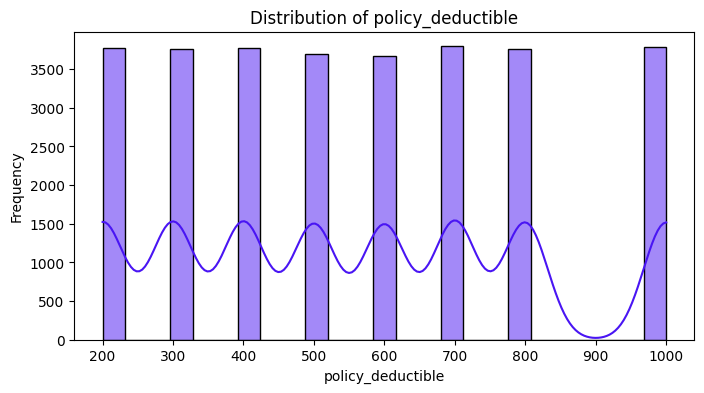

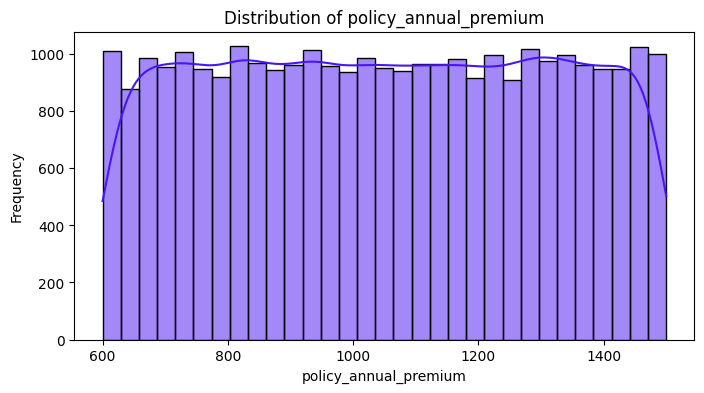

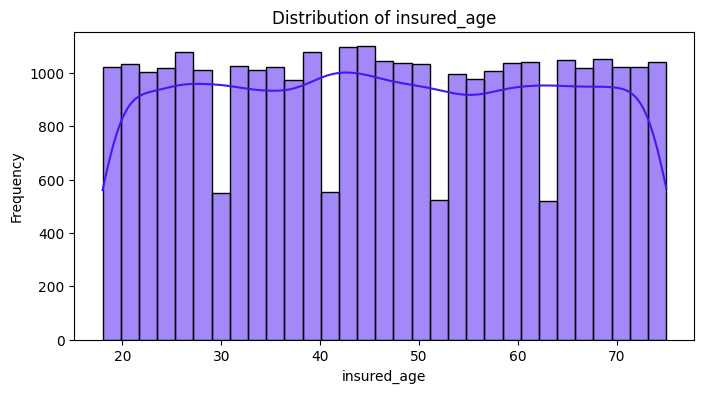

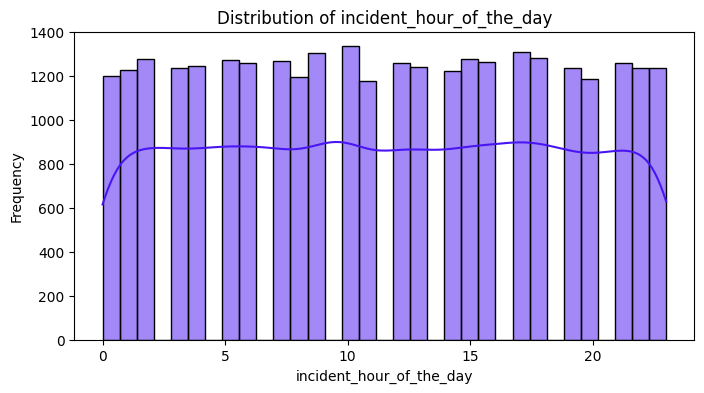

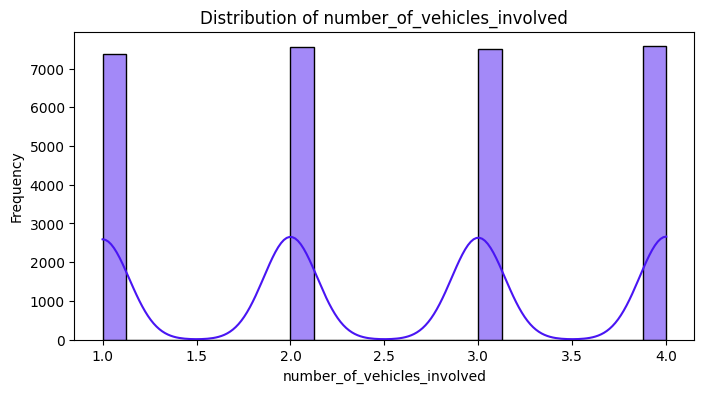

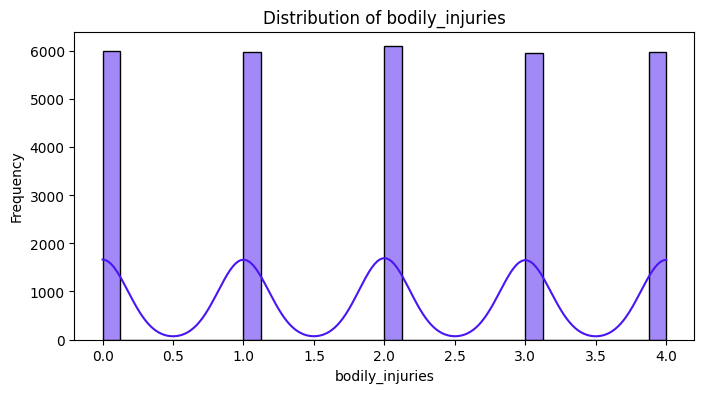

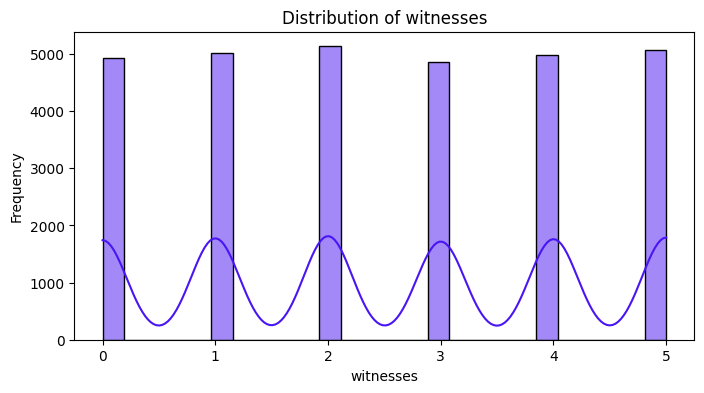

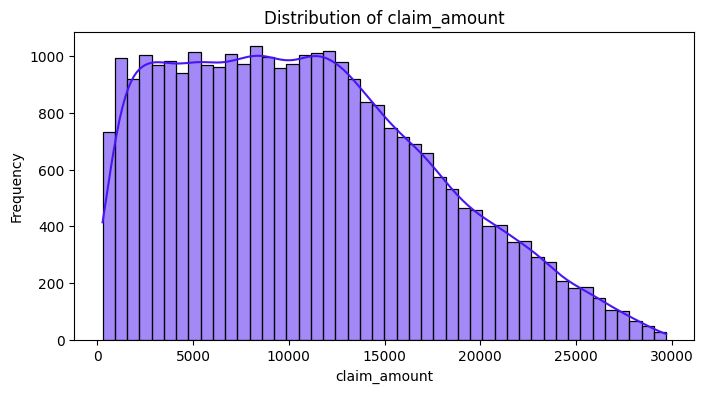

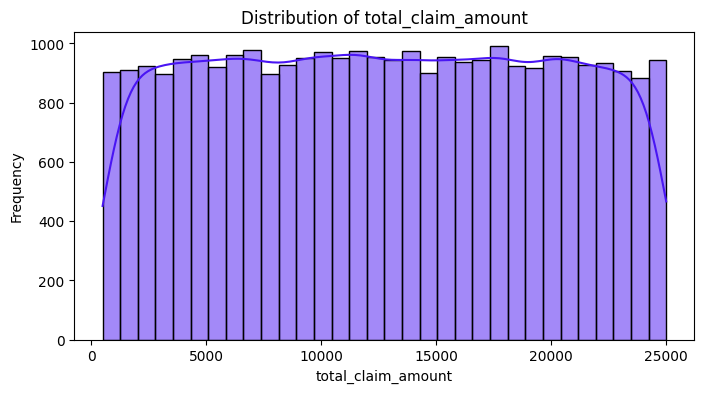

In [13]:
# Plotting the distribution of the numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True, color="#4915f3")
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [14]:
#Checking the skewness of the numerical columns
for col in numerical_cols:
    skewness = df[col].skew()
    print(f'Skewness of {col}: {skewness}')

Skewness of policy_deductible: 0.2349754188604925
Skewness of policy_annual_premium: -0.002157174725053985
Skewness of insured_age: 0.0054842796825078045
Skewness of incident_hour_of_the_day: 0.0006386146828053751
Skewness of number_of_vehicles_involved: -0.008102580831995004
Skewness of bodily_injuries: 0.002896735432756383
Skewness of witnesses: 0.0046071029958205945
Skewness of claim_amount: 0.44219278384777666
Skewness of total_claim_amount: 0.0018905007386192311


All the numerical features are evenly distributes and has very little skewness except 'claim_amount' which is slighly right skewed.

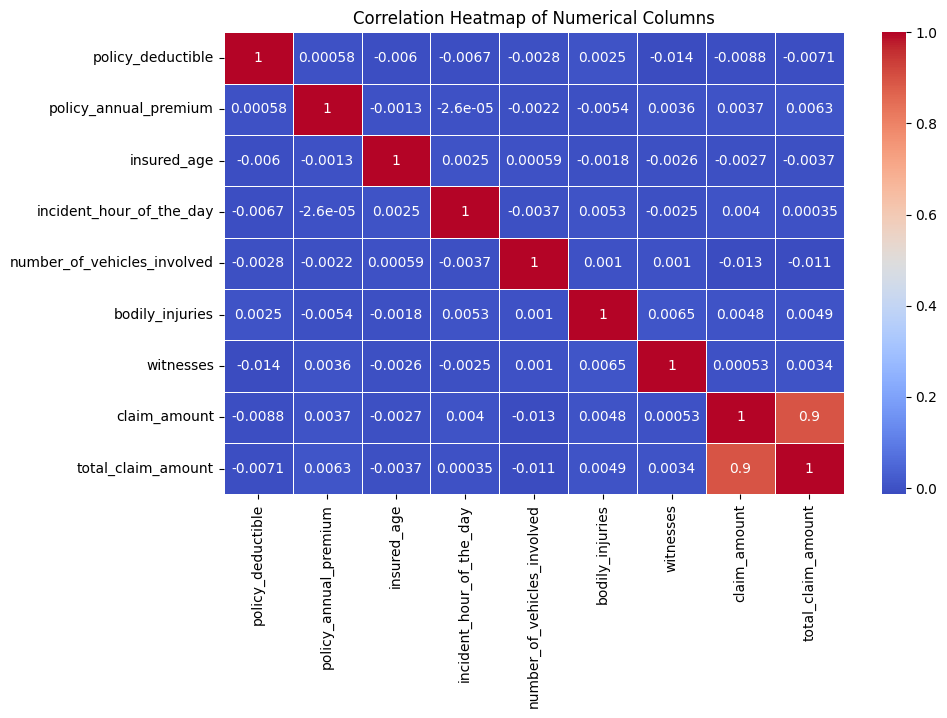

In [15]:
#Checking the correlation between the numerical columns using plotting a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df[numerical_cols].corr(), annot=True,\
             cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Columns')
plt.show()

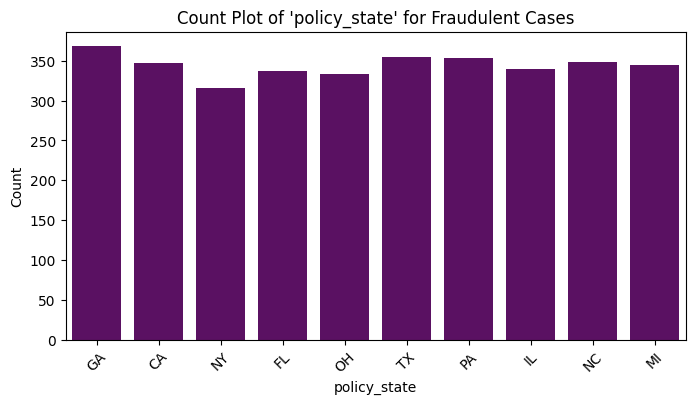

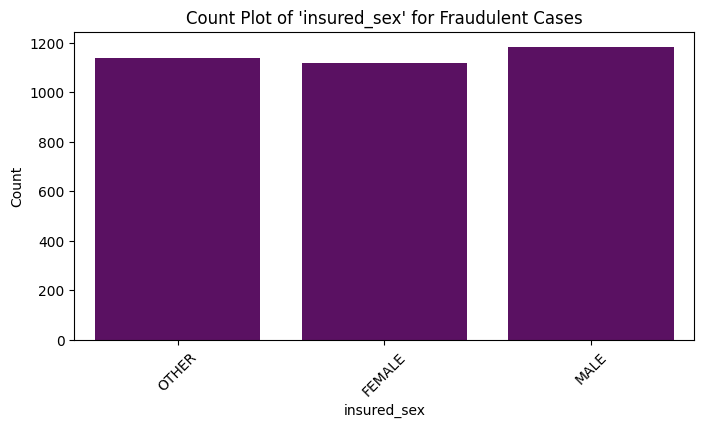

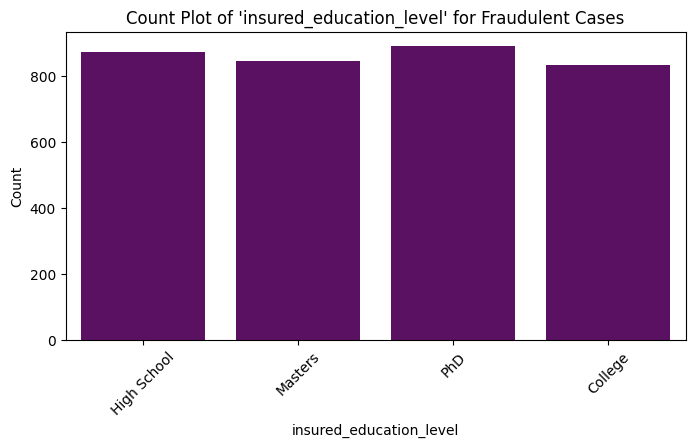

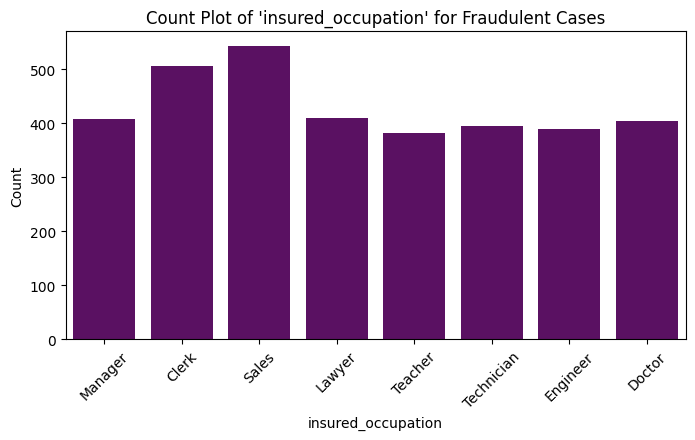

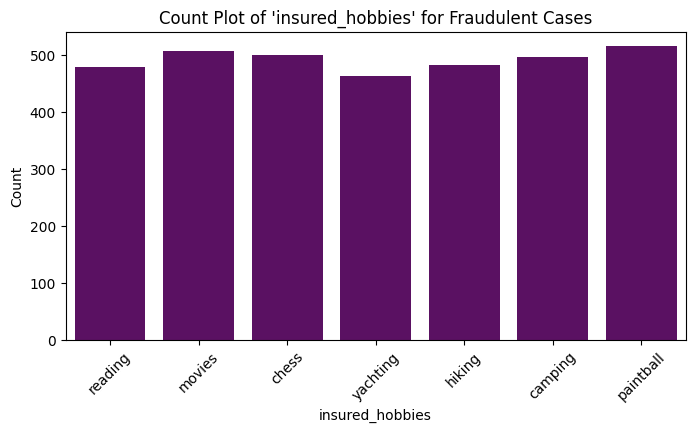

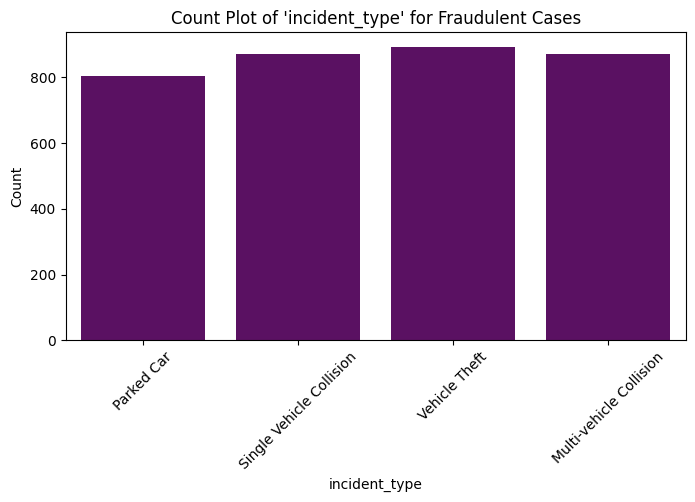

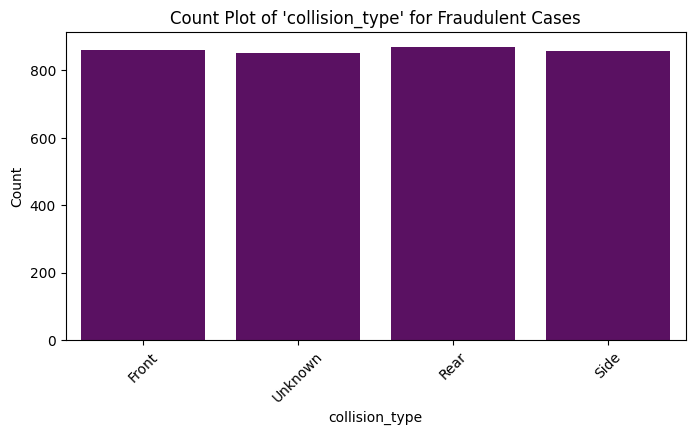

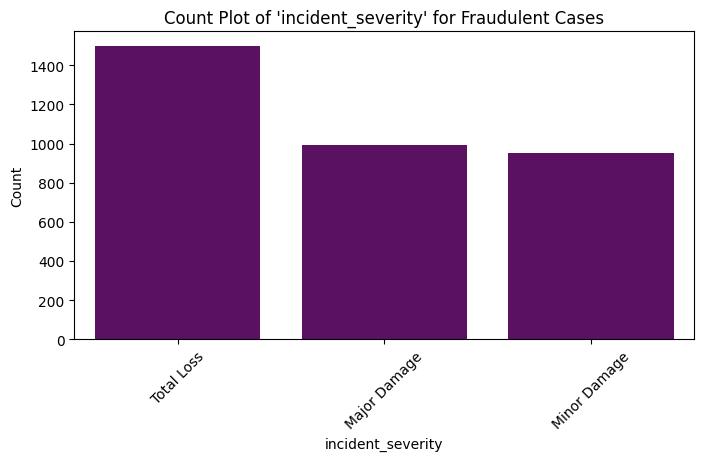

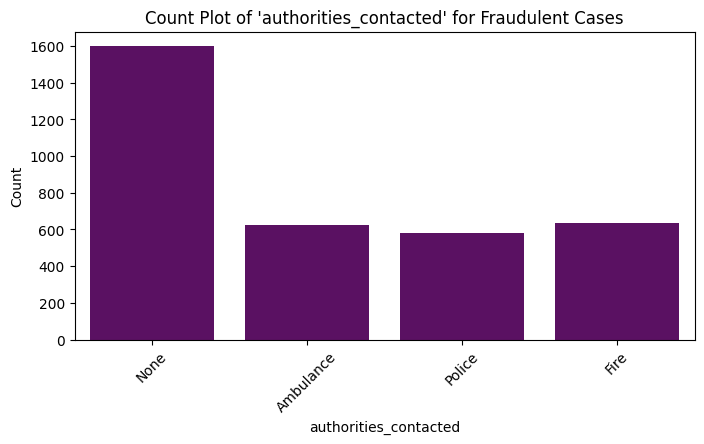

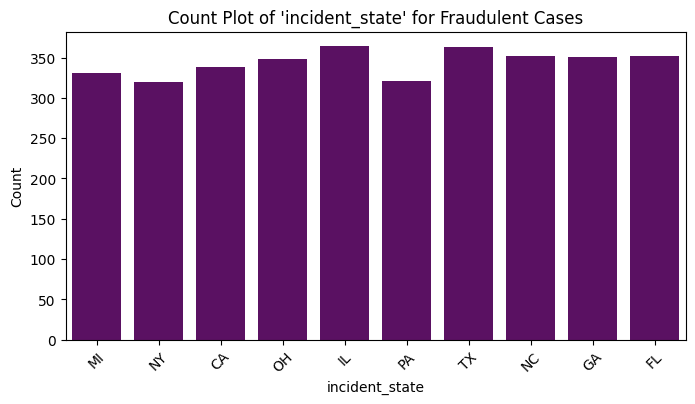

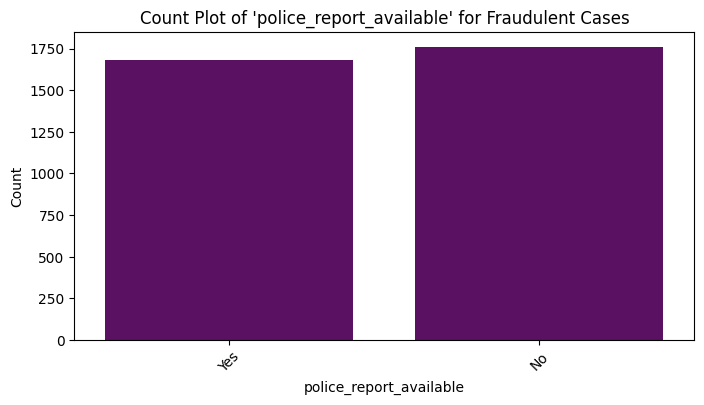

In [16]:
# Count Plot of categorical columns for fraudulent cases
for col in categorical_cols:
    if col == 'fraud_reported':
        continue
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df[df['fraud_reported'] == 'Y'], x=col,\
                  color="#65046f")
    plt.title(f"Count Plot of '{col}' for Fraudulent Cases")
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

### Preprocessing

In [17]:
# Separating the components of the 'incident_date' column into day, month and year
df['incident_date'] = pd.to_datetime(df['incident_date'], dayfirst=True)
df['incident_month'] = df['incident_date'].dt.month
df['incident_dayofweek'] = df['incident_date'].dt.dayofweek
df['is_weekend'] = df['incident_dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

# dropping the 'incident_date', 'incident_dayofweek' columns
df.drop('incident_date', axis=1, inplace=True)
df.drop('incident_dayofweek', axis=1, inplace=True)

df.head()

,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported,incident_month,is_weekend
0,GA,400,1430.78,74,OTHER,High School,Manager,reading,Parked Car,Front,Total Loss,None,MI,6,1,4,0,Yes,8161.36,11677.60,Y,6,0
1,PA,300,854.49,74,MALE,College,Lawyer,chess,Vehicle Theft,Rear,Total Loss,None,OH,0,3,4,5,No,18561.79,18027.81,N,3,1
2,MI,400,1247.28,28,OTHER,PhD,Doctor,reading,Parked Car,Unknown,Total Loss,Police,MI,14,4,4,1,No,10734.61,10375.59,N,1,1
3,CA,600,622.42,37,MALE,PhD,Teacher,yachting,Parked Car,Rear,Total Loss,Police,NC,22,3,3,5,No,13188.92,14204.34,N,6,0
4,MI,700,1458.17,31,OTHER,PhD,Sales,reading,Single Vehicle Collision,Side,Minor Damage,Fire,NY,18,4,2,4,No,21864.69,24038.84,N,5,0


In [18]:
# cyclic encoding the 'incident_month' column
df['incident_month_sin'] = np.sin(2 * np.pi * df['incident_month'] / 12)
df['incident_month_cos'] = np.cos(2 * np.pi * df['incident_month'] / 12)

# dropping the 'incident_month' column
df.drop('incident_month', axis=1, inplace=True)

In [19]:
# encoding binary features
df['fraud_reported'] = df['fraud_reported'].map({'Y': 1, 'N': 0})
df['police_report_available'] = df['police_report_available'].map({'Yes': 1, 'No': 0})

df.head()

,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported,is_weekend,incident_month_sin,incident_month_cos
0,GA,400,1430.78,74,OTHER,High School,Manager,reading,Parked Car,Front,Total Loss,None,MI,6,1,4,0,1,8161.36,11677.60,1,0,1.224647e-16,-1.000000e+00
1,PA,300,854.49,74,MALE,College,Lawyer,chess,Vehicle Theft,Rear,Total Loss,None,OH,0,3,4,5,0,18561.79,18027.81,0,1,1.000000e+00,6.123234e-17
2,MI,400,1247.28,28,OTHER,PhD,Doctor,reading,Parked Car,Unknown,Total Loss,Police,MI,14,4,4,1,0,10734.61,10375.59,0,1,5.000000e-01,8.660254e-01
3,CA,600,622.42,37,MALE,PhD,Teacher,yachting,Parked Car,Rear,Total Loss,Police,NC,22,3,3,5,0,13188.92,14204.34,0,0,1.224647e-16,-1.000000e+00
4,MI,700,1458.17,31,OTHER,PhD,Sales,reading,Single Vehicle Collision,Side,Minor Damage,Fire,NY,18,4,2,4,0,21864.69,24038.84,0,0,5.000000e-01,-8.660254e-01


In [20]:
# one-hot encoding some of the categorical columns
ohe_cols = ['insured_sex','incident_type', 'collision_type',
            'authorities_contacted']
ohe=OneHotEncoder(sparse_output=True, drop=None, dtype=int)

encoded_data = ohe.fit_transform(df[ohe_cols])
encoded_df = pd.DataFrame.sparse.from_spmatrix(
    encoded_data,
    columns=ohe.get_feature_names_out(ohe_cols),
    index=df.index)

df = pd.concat([df, encoded_df], axis=1)
df.drop(ohe_cols, axis=1, inplace=True)

df.head()

,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_education_level,insured_occupation,insured_hobbies,incident_severity,incident_state,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported,is_weekend,incident_month_sin,incident_month_cos,insured_sex_FEMALE,insured_sex_MALE,insured_sex_OTHER,incident_type_Multi-vehicle Collision,incident_type_Parked Car,incident_type_Single Vehicle Collision,incident_type_Vehicle Theft,collision_type_Front,collision_type_Rear,collision_type_Side,collision_type_Unknown,authorities_contacted_Ambulance,authorities_contacted_Fire,authorities_contacted_None,authorities_contacted_Police
0,GA,400,1430.78,74,High School,Manager,reading,Total Loss,MI,6,1,4,0,1,8161.36,11677.60,1,0,1.224647e-16,-1.000000e+00,0,0,1,0,1,0,0,1,0,0,0,0,0,1,0
1,PA,300,854.49,74,College,Lawyer,chess,Total Loss,OH,0,3,4,5,0,18561.79,18027.81,0,1,1.000000e+00,6.123234e-17,0,1,0,0,0,0,1,0,1,0,0,0,0,1,0
2,MI,400,1247.28,28,PhD,Doctor,reading,Total Loss,MI,14,4,4,1,0,10734.61,10375.59,0,1,5.000000e-01,8.660254e-01,0,0,1,0,1,0,0,0,0,0,1,0,0,0,1
3,CA,600,622.42,37,PhD,Teacher,yachting,Total Loss,NC,22,3,3,5,0,13188.92,14204.34,0,0,1.224647e-16,-1.000000e+00,0,1,0,0,1,0,0,0,1,0,0,0,0,0,1
4,MI,700,1458.17,31,PhD,Sales,reading,Minor Damage,NY,18,4,2,4,0,21864.69,24038.84,0,0,5.000000e-01,-8.660254e-01,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0


In [21]:
# Manual Ordinal encoding some other columns
df['insured_education_level'] = df['insured_education_level'].map({
    'High School': 0,
    'College': 1,
    'Masters': 2,
    'PhD': 3
})

df['incident_severity'] = df['incident_severity'].map({
    'Minor Damage': 0,
    'Major Damage': 1,
    'Total Loss': 2
})

df.head()

,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_education_level,insured_occupation,insured_hobbies,incident_severity,incident_state,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported,is_weekend,incident_month_sin,incident_month_cos,insured_sex_FEMALE,insured_sex_MALE,insured_sex_OTHER,incident_type_Multi-vehicle Collision,incident_type_Parked Car,incident_type_Single Vehicle Collision,incident_type_Vehicle Theft,collision_type_Front,collision_type_Rear,collision_type_Side,collision_type_Unknown,authorities_contacted_Ambulance,authorities_contacted_Fire,authorities_contacted_None,authorities_contacted_Police
0,GA,400,1430.78,74,0,Manager,reading,2,MI,6,1,4,0,1,8161.36,11677.60,1,0,1.224647e-16,-1.000000e+00,0,0,1,0,1,0,0,1,0,0,0,0,0,1,0
1,PA,300,854.49,74,1,Lawyer,chess,2,OH,0,3,4,5,0,18561.79,18027.81,0,1,1.000000e+00,6.123234e-17,0,1,0,0,0,0,1,0,1,0,0,0,0,1,0
2,MI,400,1247.28,28,3,Doctor,reading,2,MI,14,4,4,1,0,10734.61,10375.59,0,1,5.000000e-01,8.660254e-01,0,0,1,0,1,0,0,0,0,0,1,0,0,0,1
3,CA,600,622.42,37,3,Teacher,yachting,2,NC,22,3,3,5,0,13188.92,14204.34,0,0,1.224647e-16,-1.000000e+00,0,1,0,0,1,0,0,0,1,0,0,0,0,0,1
4,MI,700,1458.17,31,3,Sales,reading,0,NY,18,4,2,4,0,21864.69,24038.84,0,0,5.000000e-01,-8.660254e-01,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0


#### Preprocessing for Tree-Based Model

In [22]:
# Making a copy of the dataframe for Tree-based models
df_tree = df.copy()
df_tree.head()

,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_education_level,insured_occupation,insured_hobbies,incident_severity,incident_state,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported,is_weekend,incident_month_sin,incident_month_cos,insured_sex_FEMALE,insured_sex_MALE,insured_sex_OTHER,incident_type_Multi-vehicle Collision,incident_type_Parked Car,incident_type_Single Vehicle Collision,incident_type_Vehicle Theft,collision_type_Front,collision_type_Rear,collision_type_Side,collision_type_Unknown,authorities_contacted_Ambulance,authorities_contacted_Fire,authorities_contacted_None,authorities_contacted_Police
0,GA,400,1430.78,74,0,Manager,reading,2,MI,6,1,4,0,1,8161.36,11677.60,1,0,1.224647e-16,-1.000000e+00,0,0,1,0,1,0,0,1,0,0,0,0,0,1,0
1,PA,300,854.49,74,1,Lawyer,chess,2,OH,0,3,4,5,0,18561.79,18027.81,0,1,1.000000e+00,6.123234e-17,0,1,0,0,0,0,1,0,1,0,0,0,0,1,0
2,MI,400,1247.28,28,3,Doctor,reading,2,MI,14,4,4,1,0,10734.61,10375.59,0,1,5.000000e-01,8.660254e-01,0,0,1,0,1,0,0,0,0,0,1,0,0,0,1
3,CA,600,622.42,37,3,Teacher,yachting,2,NC,22,3,3,5,0,13188.92,14204.34,0,0,1.224647e-16,-1.000000e+00,0,1,0,0,1,0,0,0,1,0,0,0,0,0,1
4,MI,700,1458.17,31,3,Sales,reading,0,NY,18,4,2,4,0,21864.69,24038.84,0,0,5.000000e-01,-8.660254e-01,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0


In [23]:
# encoding the remaining categorical columns using Label Encoding
label= LabelEncoder()
df_tree['policy_state'] = label.fit_transform(df_tree['policy_state'])
df_tree['insured_occupation'] = label.fit_transform(df_tree['insured_occupation'])
df_tree['insured_hobbies'] = label.fit_transform(df_tree['insured_hobbies'])
df_tree['incident_state'] = label.fit_transform(df_tree['incident_state'])

df_tree.head()

,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_education_level,insured_occupation,insured_hobbies,incident_severity,incident_state,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported,is_weekend,incident_month_sin,incident_month_cos,insured_sex_FEMALE,insured_sex_MALE,insured_sex_OTHER,incident_type_Multi-vehicle Collision,incident_type_Parked Car,incident_type_Single Vehicle Collision,incident_type_Vehicle Theft,collision_type_Front,collision_type_Rear,collision_type_Side,collision_type_Unknown,authorities_contacted_Ambulance,authorities_contacted_Fire,authorities_contacted_None,authorities_contacted_Police
0,2,400,1430.78,74,0,4,5,2,4,6,1,4,0,1,8161.36,11677.60,1,0,1.224647e-16,-1.000000e+00,0,0,1,0,1,0,0,1,0,0,0,0,0,1,0
1,8,300,854.49,74,1,3,1,2,7,0,3,4,5,0,18561.79,18027.81,0,1,1.000000e+00,6.123234e-17,0,1,0,0,0,0,1,0,1,0,0,0,0,1,0
2,4,400,1247.28,28,3,1,5,2,4,14,4,4,1,0,10734.61,10375.59,0,1,5.000000e-01,8.660254e-01,0,0,1,0,1,0,0,0,0,0,1,0,0,0,1
3,0,600,622.42,37,3,6,6,2,5,22,3,3,5,0,13188.92,14204.34,0,0,1.224647e-16,-1.000000e+00,0,1,0,0,1,0,0,0,1,0,0,0,0,0,1
4,4,700,1458.17,31,3,5,5,0,6,18,4,2,4,0,21864.69,24038.84,0,0,5.000000e-01,-8.660254e-01,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0


In [24]:
df_tree.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 35 columns):
 #   Column                                  Non-Null Count  Dtype           
---  ------                                  --------------  -----           
 0   policy_state                            30000 non-null  int64           
 1   policy_deductible                       30000 non-null  int64           
 2   policy_annual_premium                   30000 non-null  float64         
 3   insured_age                             30000 non-null  int64           
 4   insured_education_level                 30000 non-null  int64           
 5   insured_occupation                      30000 non-null  int64           
 6   insured_hobbies                         30000 non-null  int64           
 7   incident_severity                       30000 non-null  int64           
 8   incident_state                          30000 non-null  int64           
 9   incident_hour_of_the_day    

#### Preprocessing for Logistic Regression

In [25]:
df.head()

,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_education_level,insured_occupation,insured_hobbies,incident_severity,incident_state,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported,is_weekend,incident_month_sin,incident_month_cos,insured_sex_FEMALE,insured_sex_MALE,insured_sex_OTHER,incident_type_Multi-vehicle Collision,incident_type_Parked Car,incident_type_Single Vehicle Collision,incident_type_Vehicle Theft,collision_type_Front,collision_type_Rear,collision_type_Side,collision_type_Unknown,authorities_contacted_Ambulance,authorities_contacted_Fire,authorities_contacted_None,authorities_contacted_Police
0,GA,400,1430.78,74,0,Manager,reading,2,MI,6,1,4,0,1,8161.36,11677.60,1,0,1.224647e-16,-1.000000e+00,0,0,1,0,1,0,0,1,0,0,0,0,0,1,0
1,PA,300,854.49,74,1,Lawyer,chess,2,OH,0,3,4,5,0,18561.79,18027.81,0,1,1.000000e+00,6.123234e-17,0,1,0,0,0,0,1,0,1,0,0,0,0,1,0
2,MI,400,1247.28,28,3,Doctor,reading,2,MI,14,4,4,1,0,10734.61,10375.59,0,1,5.000000e-01,8.660254e-01,0,0,1,0,1,0,0,0,0,0,1,0,0,0,1
3,CA,600,622.42,37,3,Teacher,yachting,2,NC,22,3,3,5,0,13188.92,14204.34,0,0,1.224647e-16,-1.000000e+00,0,1,0,0,1,0,0,0,1,0,0,0,0,0,1
4,MI,700,1458.17,31,3,Sales,reading,0,NY,18,4,2,4,0,21864.69,24038.84,0,0,5.000000e-01,-8.660254e-01,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0


In [26]:
#One-hot encoding the remaining categorical columns
cols=['policy_state', 'insured_occupation',
       'insured_hobbies', 'incident_state']
ohe = OneHotEncoder(sparse_output=True, drop=None, dtype=int)

encoded_data = ohe.fit_transform(df[cols])

encoded_df = pd.DataFrame.sparse.from_spmatrix(
    encoded_data,
    columns=ohe.get_feature_names_out(cols),
    index=df.index
)

df = pd.concat([df.drop(columns=cols), encoded_df], axis=1)

df.head()

,policy_deductible,policy_annual_premium,insured_age,insured_education_level,incident_severity,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported,is_weekend,incident_month_sin,incident_month_cos,insured_sex_FEMALE,insured_sex_MALE,insured_sex_OTHER,incident_type_Multi-vehicle Collision,incident_type_Parked Car,incident_type_Single Vehicle Collision,incident_type_Vehicle Theft,collision_type_Front,collision_type_Rear,collision_type_Side,collision_type_Unknown,authorities_contacted_Ambulance,authorities_contacted_Fire,authorities_contacted_None,authorities_contacted_Police,policy_state_CA,policy_state_FL,policy_state_GA,policy_state_IL,policy_state_MI,policy_state_NC,policy_state_NY,policy_state_OH,policy_state_PA,policy_state_TX,insured_occupation_Clerk,insured_occupation_Doctor,insured_occupation_Engineer,insured_occupation_Lawyer,insured_occupation_Manager,insured_occupation_Sales,insured_occupation_Teacher,insured_occupation_Technician,insured_hobbies_camping,insured_hobbies_chess,insured_hobbies_hiking,insured_hobbies_movies,insured_hobbies_paintball,insured_hobbies_reading,insured_hobbies_yachting,incident_state_CA,incident_state_FL,incident_state_GA,incident_state_IL,incident_state_MI,incident_state_NC,incident_state_NY,incident_state_OH,incident_state_PA,incident_state_TX
0,400,1430.78,74,0,2,6,1,4,0,1,8161.36,11677.60,1,0,1.224647e-16,-1.000000e+00,0,0,1,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0
1,300,854.49,74,1,2,0,3,4,5,0,18561.79,18027.81,0,1,1.000000e+00,6.123234e-17,0,1,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,400,1247.28,28,3,2,14,4,4,1,0,10734.61,10375.59,0,1,5.000000e-01,8.660254e-01,0,0,1,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0
3,600,622.42,37,3,2,22,3,3,5,0,13188.92,14204.34,0,0,1.224647e-16,-1.000000e+00,0,1,0,0,1,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
4,700,1458.17,31,3,0,18,4,2,4,0,21864.69,24038.84,0,0,5.000000e-01,-8.660254e-01,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0


In [27]:
#scale the numerical features using StandardScaler
scale_col=['policy_deductible', 'policy_annual_premium',
           'insured_age','insured_education_level','incident_severity',
           'incident_hour_of_the_day','number_of_vehicles_involved',
           'bodily_injuries','witnesses','claim_amount',
           'total_claim_amount']
scaler=StandardScaler()

df[scale_col] = scaler.fit_transform(df[scale_col])


In [28]:
df.head()

,policy_deductible,policy_annual_premium,insured_age,insured_education_level,incident_severity,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported,is_weekend,incident_month_sin,incident_month_cos,insured_sex_FEMALE,insured_sex_MALE,insured_sex_OTHER,incident_type_Multi-vehicle Collision,incident_type_Parked Car,incident_type_Single Vehicle Collision,incident_type_Vehicle Theft,collision_type_Front,collision_type_Rear,collision_type_Side,collision_type_Unknown,authorities_contacted_Ambulance,authorities_contacted_Fire,authorities_contacted_None,authorities_contacted_Police,policy_state_CA,policy_state_FL,policy_state_GA,policy_state_IL,policy_state_MI,policy_state_NC,policy_state_NY,policy_state_OH,policy_state_PA,policy_state_TX,insured_occupation_Clerk,insured_occupation_Doctor,insured_occupation_Engineer,insured_occupation_Lawyer,insured_occupation_Manager,insured_occupation_Sales,insured_occupation_Teacher,insured_occupation_Technician,insured_hobbies_camping,insured_hobbies_chess,insured_hobbies_hiking,insured_hobbies_movies,insured_hobbies_paintball,insured_hobbies_reading,insured_hobbies_yachting,incident_state_CA,incident_state_FL,incident_state_GA,incident_state_IL,incident_state_MI,incident_state_NC,incident_state_NY,incident_state_OH,incident_state_PA,incident_state_TX
0,-0.650070,1.457733,1.645959,-1.337758,1.215944,-0.798284,-1.351441,1.418326,-1.466722,1,-0.401491,-0.153673,1,0,1.224647e-16,-1.000000e+00,0,0,1,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0
1,-1.049417,-0.755764,1.645959,-0.444947,1.215944,-1.668349,0.439813,1.418326,1.461257,0,1.167300,0.749782,0,1,1.000000e+00,6.123234e-17,0,1,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,-0.650070,0.752920,-1.107295,1.340674,1.215944,0.361802,1.335439,1.418326,-0.881126,0,-0.013345,-0.338912,0,1,5.000000e-01,8.660254e-01,0,0,1,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0
3,0.148624,-1.647131,-0.568615,1.340674,1.215944,1.521888,0.439813,0.710013,1.461257,0,0.356861,0.205811,0,0,1.224647e-16,-1.000000e+00,0,1,0,0,1,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
4,0.547971,1.562936,-0.927735,1.340674,-1.233827,0.941845,1.335439,0.001700,0.875661,0,1.665507,1.604982,0,0,5.000000e-01,-8.660254e-01,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 66 columns):
 #   Column                                  Non-Null Count  Dtype           
---  ------                                  --------------  -----           
 0   policy_deductible                       30000 non-null  float64         
 1   policy_annual_premium                   30000 non-null  float64         
 2   insured_age                             30000 non-null  float64         
 3   insured_education_level                 30000 non-null  float64         
 4   incident_severity                       30000 non-null  float64         
 5   incident_hour_of_the_day                30000 non-null  float64         
 6   number_of_vehicles_involved             30000 non-null  float64         
 7   bodily_injuries                         30000 non-null  float64         
 8   witnesses                               30000 non-null  float64         
 9   police_report_available     

### Model Building

In [30]:
#Train-test split of 'df'
x=df.drop('fraud_reported', axis=1)
y=df['fraud_reported']
x_train, x_test, y_train, y_test = train_test_split\
                            (x, y, test_size=0.2,\
                            random_state=42)

In [31]:
#Train-test split of 'df_tree'
x_tree=df_tree.drop('fraud_reported', axis=1)
y_tree=df_tree['fraud_reported']
x_train_tree, x_test_tree, y_train_tree, y_test_tree = \
            train_test_split\
            (x_tree, y_tree, test_size=0.2,\
            random_state=42)

#### Decision Tree Model

In [32]:
#training the Decision Tree Classifier
dt= DecisionTreeClassifier()
dt.fit(x_train_tree, y_train_tree)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [33]:
# Predicting the target variable for the test set
y_pred_dt = dt.predict(x_test_tree)

In [34]:
#Accuracy of the Decision Tree Classifier
accuracy_dt = accuracy_score(y_test_tree, y_pred_dt)
confusion_matrix_dt = confusion_matrix(y_test_tree, y_pred_dt)
print(f'Accuracy of Decision Tree Classifier: {accuracy_dt*100:.2f}%')
print(f'Confusion Matrix of Decision Tree Classifier:\n {confusion_matrix_dt}')

Accuracy of Decision Tree Classifier: 82.12%
Confusion Matrix of Decision Tree Classifier:
 [[4744  568]
 [ 505  183]]


#### Random Forest Model

In [35]:
# Training the Random Forest Classifier
rf= RandomForestClassifier(random_state=42)
rf.fit(x_train_tree, y_train_tree)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [36]:
# Predicting the target variable for the test set
y_pred_rf = rf.predict(x_test_tree)

In [37]:
# Accuracy of the Random Forest Classifier
accuracy_rf = accuracy_score(y_test_tree, y_pred_rf)
confusion_matrix_rf = confusion_matrix(y_test_tree, y_pred_rf)
print(f'Accuracy of Random Forest Classifier: {accuracy_rf*100:.2f}%')
print(f'Confusion Matrix of Random Forest Classifier:\n {confusion_matrix_rf}')

Accuracy of Random Forest Classifier: 88.52%
Confusion Matrix of Random Forest Classifier:
 [[5310    2]
 [ 687    1]]


#### Logistic Regression

In [38]:
# Training the Logistic Regression Classifier
lr= LogisticRegression(random_state=42)
lr.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [39]:
# Predicting the target variable for the test set
y_pred_lr = lr.predict(x_test)

In [40]:
# Accuracy of the Logistic Regression Classifier
accuracy_lr = accuracy_score(y_test, y_pred_lr)
confusion_matrix_lr = confusion_matrix(y_test, y_pred_lr)
print(f'Accuracy of Logistic Regression Classifier: {accuracy_lr*100:.2f}%')
print(f'Confusion Matrix of Logistic Regression Classifier:\n {confusion_matrix_lr}')

Accuracy of Logistic Regression Classifier: 88.48%
Confusion Matrix of Logistic Regression Classifier:
 [[5309    3]
 [ 688    0]]
